In [1]:
%reset
import numpy as np
import torch
import torch.nn as nn
import scipy.io
import matplotlib.tri as mtri

from scipy.stats import qmc
import matplotlib.pyplot as plt

Nothing done.


In [2]:
# -----------------------
# Reproducibility + dtype
# -----------------------
np.random.seed(0)
torch.manual_seed(0)

DTYPE = torch.float64
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
# -----------------------
# Load data (cylinder_nektar_wake.mat)
# -----------------------
data = scipy.io.loadmat("./data/cylinder_nektar_wake.mat")

X_star = data["X_star"]          # (N, 2)
x = X_star[:, 0:1]               # (N, 1)
y = X_star[:, 1:2]               # (N, 1)

t = data["t"]                    # (nt, 1)

U_star = data["U_star"]          # (N, 2, nt)
u = U_star[:, 0, :]              # (N, nt)
v = U_star[:, 1, :]              # (N, nt)

p = data["p_star"]               # (N, nt) (optional, not used below)

print("x:", x.shape, "y:", y.shape, "t:", t.shape)
print("u:", u.shape, "v:", v.shape, "p:", p.shape)



x: (5000, 1) y: (5000, 1) t: (200, 1)
u: (5000, 200) v: (5000, 200) p: (5000, 200)


In [4]:
# -----------------------
# Build snapshots matrix X for POD
# -----------------------
X = u


In [ ]:
# -----------------------
# Train/test split
# -----------------------
nt = X.shape[1]
train_frac = 0.7
k_split = int(train_frac * nt)

train_idx = np.arange(0, k_split)
test_idx = np.arange(k_split, nt)

t1 = t.reshape(-1)
dt = float(t1[1] - t1[0])

# -----------------------
# Train/test data
# -----------------------
Xtr = X[:, train_idx]  # (N, nt_train)
Xte = X[:, test_idx]  # (N, nt_test)

t_train = t1[train_idx]
t_test = t1[test_idx]
dt = float(t1[1] - t1[0])

# Mean subtraction (use training mean)
mean_field = Xtr.mean(axis=1, keepdims=True)  # (N, 1)
Xtr_c = Xtr - mean_field
Xte_c = Xte - mean_field

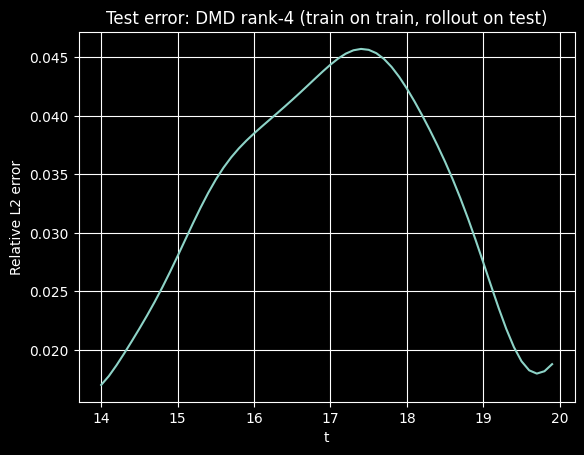

In [5]:
# -----------------------
# Build DMD snapshot pairs from TRAIN
# -----------------------
X1 = Xtr_c[:, :-1]  # (N, nt_train-1)
X2 = Xtr_c[:, 1:]  # (N, nt_train-1)

# -----------------------
# Rank-4 DMD
# -----------------------
r_dmd = 4
U, S, Vt = np.linalg.svd(X1, full_matrices=False)
Ur = U[:, :r_dmd]
Sr = np.diag(S[:r_dmd])
Vr = Vt[:r_dmd, :].T  # (nt_train-1, r)

# Reduced operator
Atilde = Ur.T @ X2 @ Vr @ np.linalg.inv(Sr)  # (r, r)

# Eigen-decomposition
eigvals, W = np.linalg.eig(Atilde)  # eigvals: (r,), W: (r,r)

# DMD modes (exact DMD)
Phi = X2 @ Vr @ np.linalg.inv(Sr) @ W  # (N, r)

# -----------------------
# Fit initial amplitudes from first TEST snapshot
# -----------------------
x0 = Xte_c[:, 0]  # (N,)
b = np.linalg.lstsq(Phi, x0, rcond=None)[0]  # (r,)

# -----------------------
# Predict over TEST times
# x_k = Phi * diag(eigvals^k) * b
# -----------------------
nt_test = Xte.shape[1]
powers = np.arange(nt_test)  # 0..nt_test-1
Lambda_pows = eigvals[None, :] ** powers[:, None]  # (nt_test, r)

X_pred_c = (Phi @ (b[None, :] * Lambda_pows).T)  # (N, nt_test)
X_pred = mean_field + X_pred_c  # add mean back

# -----------------------
# Test error
# -----------------------
err = np.linalg.norm(Xte - X_pred, axis=0) / np.linalg.norm(Xte, axis=0)

plt.figure()
plt.plot(t_test, err)
plt.xlabel("t")
plt.ylabel("Relative L2 error")
plt.title("Test error: DMD rank-4 (train on train, rollout on test)")
plt.grid(True)
plt.show()

/opt/anaconda3/envs/ML/lib/python3.10/site-packages/matplotlib/tri/_tricontour.py:73: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmax = float(z_check.max())
/opt/anaconda3/envs/ML/lib/python3.10/site-packages/matplotlib/tri/_tricontour.py:74: ComplexWarning: Casting complex values to real discards the imaginary part
  self.zmin = float(z_check.min())
/opt/anaconda3/envs/ML/lib/python3.10/site-packages/matplotlib/tri/_tricontour.py:46: ComplexWarning: Casting complex values to real discards the imaginary part
  C = _tri.TriContourGenerator(tri.get_cpp_triangulation(), z)


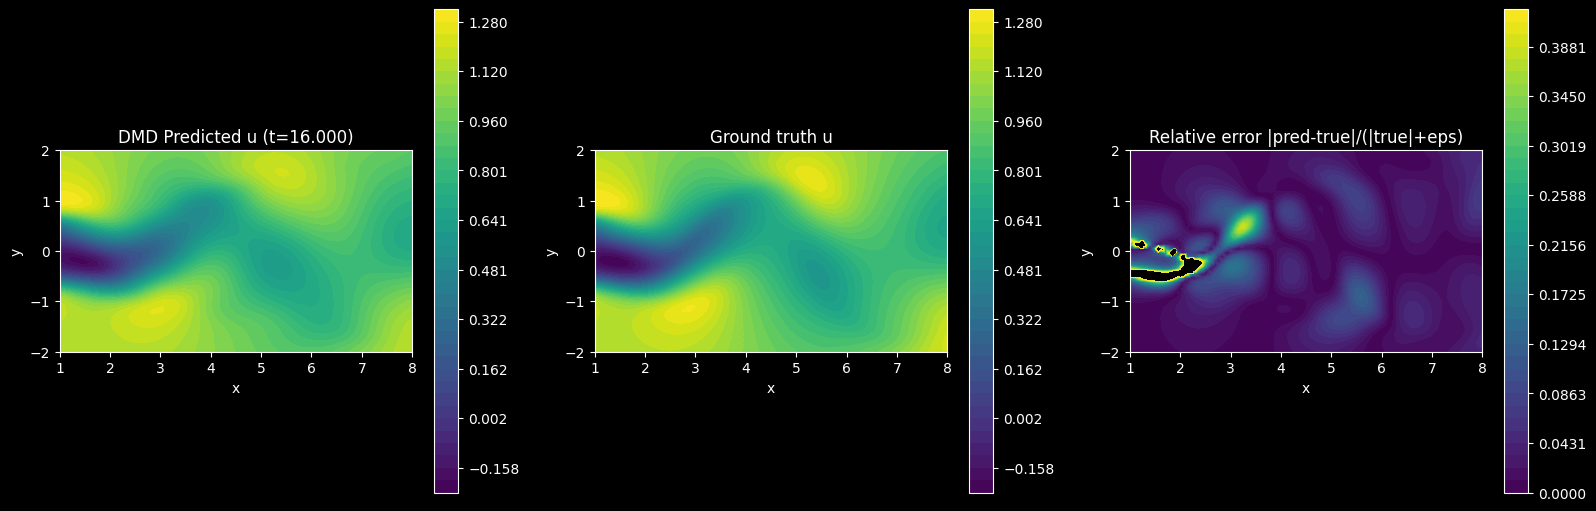

In [6]:
k_plot = min(20, nt_test - 1)

xg = X_star[:, 0].reshape(-1)
yg = X_star[:, 1].reshape(-1)

u_pred = X_pred[:, k_plot].reshape(-1)
u_true = Xte[:, k_plot].reshape(-1)

eps = 1e-12
rel_err = np.abs(u_pred - u_true) / (np.abs(u_true) + eps)

tri = mtri.Triangulation(xg, yg)

fig, axs = plt.subplots(1, 3, figsize=(16, 5), constrained_layout=True)

vmin = min(u_true.min(), u_pred.min())
vmax = max(u_true.max(), u_pred.max())
levels = np.linspace(vmin, vmax, 40)

c0 = axs[0].tricontourf(tri, u_pred, levels=levels)
fig.colorbar(c0, ax=axs[0])
axs[0].set_title(f"DMD Predicted u (t={t_test[k_plot]:.3f})")
axs[0].set_xlabel("x"); axs[0].set_ylabel("y")
axs[0].set_aspect("equal")

c1 = axs[1].tricontourf(tri, u_true, levels=levels)
fig.colorbar(c1, ax=axs[1])
axs[1].set_title("Ground truth u")
axs[1].set_xlabel("x"); axs[1].set_ylabel("y")
axs[1].set_aspect("equal")

err_levels = np.linspace(0, np.percentile(rel_err, 99), 40)
c2 = axs[2].tricontourf(tri, rel_err, levels=err_levels)
fig.colorbar(c2, ax=axs[2])
axs[2].set_title("Relative error |pred-true|/(|true|+eps)")
axs[2].set_xlabel("x"); axs[2].set_ylabel("y")
axs[2].set_aspect("equal")

plt.show()